In [16]:
# 2.3.1. Импорты, seed и настройка окружения
import os
import json
import random
import re
import textwrap
from typing import List, Dict, Tuple, Any

import numpy as np
import pandas as pd
import sklearn  # Обязательный импорт согласно требованиям
import matplotlib.pyplot as plt
import faiss
import torch

# Фиксация seed для воспроизводимости всех стохастических операций
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# Определение устройства (GPU при наличии, иначе CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используется устройство: {device}")
print(f"Seed зафиксирован: {SEED}")

# Создаём папку для артефактов, если её нет
ARTIFACTS_DIR = "artifacts"
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

Используется устройство: cpu
Seed зафиксирован: 42


In [17]:
# 2.3.2. База знаний и первичный анализ

# Создаём учебную БЗ (15 документов по теме "Docker для разработчиков")
# Генерация в коде гарантирует полную воспроизводимость без внешних загрузок
knowledge_base_raw = [
    {"id": 1, "title": "Что такое Docker", "text": "Docker — это платформа для разработки, доставки и запуска приложений в контейнерах. Контейнеры изолируют приложения от хост-системы, обеспечивая воспроизводимость окружения. Docker использует образы (images) для создания контейнеров."},
    {"id": 2, "title": "Основные команды Docker", "text": "docker run запускает контейнер из образа. docker ps показывает запущенные контейнеры. docker images выводит список загруженных образов. docker stop останавливает контейнер, а docker rm удаляет его."},
    {"id": 3, "title": "Dockerfile", "text": "Dockerfile — это текстовый файл с инструкциями по сборке образа. Команда FROM задаёт базовый образ, RUN выполняет команды в процессе сборки, COPY копирует файлы в образ, а CMD определяет команду по умолчанию при запуске контейнера."},
    {"id": 4, "title": "Сети в Docker", "text": "По умолчанию контейнеры подключаются к мостовой сети (bridge). Для изоляции или межконтейнерного взаимодействия создают пользовательские сети командой docker network create. Контейнеры в одной сети видят друг друга по именам."},
    {"id": 5, "title": "Тома (Volumes)", "text": "Тома используются для хранения данных вне файловой системы контейнера. Они сохраняются после удаления контейнера. Управляются через docker volume create и монтируются флагом -v."},
    {"id": 6, "title": "Docker Compose", "text": "Docker Compose — инструмент для запуска мультиконтейнерных приложений. Конфигурация описывается в файле docker-compose.yml формата YAML. Позволяет запускать, останавливать и управлять связанными контейнерами одной командой docker compose up."},
    {"id": 7, "title": "Реестры образов", "text": "Реестр (registry) — хранилище Docker-образов. Docker Hub является публичным реестром по умолчанию. Команда docker push загружает образ, а docker pull скачивает его. Можно развернуть приватный реестр."},
    {"id": 8, "title": "Жизненный цикл контейнера", "text": "Контейнер проходит состояния: created → running → paused → stopped. Команда docker start возобновляет остановленный контейнер без пересборки. Команда docker exec позволяет выполнить команду в работающем контейнере."},
    {"id": 9, "title": "Ограничение ресурсов", "text": "Docker позволяет ограничивать CPU и память контейнеров. Флаги --memory и --cpus задают жёсткие лимиты. Это предотвращает захват ресурсов одним контейнером и повышает стабильность хоста."},
    {"id": 10, "title": "Безопасность контейнеров", "text": "Контейнеры не являются полной изоляцией. Рекомендуется запускать процессы от непривилегированного пользователя, использовать Read-Only файловую систему (--read-only) и регулярно обновлять базовые образы."},
    {"id": 11, "title": "Очистка Docker", "text": "Команда docker system prune удаляет неиспользуемые образы, контейнеры, сети и кэш. docker volume prune очищает неиспользуемые тома. Рекомендуется регулярно запускать очистку для освобождения места."},
    {"id": 12, "title": "Логи и мониторинг", "text": "Логи контейнера доступны через docker logs. Для production-сред используют драйверы логирования (json-file, syslog, fluentd). Мониторинг ресурсов возможен через docker stats или внешние системы (Prometheus, Grafana)."},
    {"id": 13, "title": "Мультистадийная сборка", "text": "Мультистадийная сборка (multi-stage build) позволяет использовать несколько FROM в одном Dockerfile. Первый этап компилирует код, второй копирует только артефакты. Это значительно уменьшает итоговый размер образа."},
    {"id": 14, "title": "Переменные окружения", "text": "Переменные окружения передаются в контейнер через флаг -e или файл .env. В Docker Compose они указываются в секции environment. Позволяют конфигурировать приложение без изменения образа."},
    {"id": 15, "title": "Ошибки и отладка", "text": "Частые ошибки: порт занят (EADDRINUSE), отсутствие прав на том (permission denied), выход контейнера с кодом 1. Для отладки используют docker logs, docker inspect и запуск контейнера в интерактивном режиме docker run -it."}
]

# Сохраняем БЗ в артефакты для воспроизводимости
KB_PATH = os.path.join(ARTIFACTS_DIR, "knowledge_base.json")
with open(KB_PATH, "w", encoding="utf-8") as f:
    json.dump(knowledge_base_raw, f, ensure_ascii=False, indent=2)

# Загружаем обратно (имитация рабочего пайплайна)
with open(KB_PATH, "r", encoding="utf-8") as f:
    KB = json.load(f)

print(f"Количество документов в базе: {len(KB)}")
print("Примеры документов (первые 3):")
for doc in KB[:3]:
    print(f"--- [{doc['id']}] {doc['title']}")
    print(textwrap.shorten(doc['text'], width=120))
    print()

# Пояснение области
print("Предметная область: Основы контейнеризации (Docker).")
print("Почему подходит для retrieval/RAG: документы структурны, содержат термины, команды и концепции.")
print("Запросы по этой теме требуют точного поиска фрагментов (команды, флаги, этапы), что идеально проверяет векторный поиск.")

Количество документов в базе: 15
Примеры документов (первые 3):
--- [1] Что такое Docker
Docker — это платформа для разработки, доставки и запуска приложений в контейнерах. Контейнеры изолируют [...]

--- [2] Основные команды Docker
docker run запускает контейнер из образа. docker ps показывает запущенные контейнеры. docker images выводит список [...]

--- [3] Dockerfile
Dockerfile — это текстовый файл с инструкциями по сборке образа. Команда FROM задаёт базовый образ, RUN выполняет [...]

Предметная область: Основы контейнеризации (Docker).
Почему подходит для retrieval/RAG: документы структурны, содержат термины, команды и концепции.
Запросы по этой теме требуют точного поиска фрагментов (команды, флаги, этапы), что идеально проверяет векторный поиск.


In [18]:
# 2.3.3. Чанкинг документов

def chunk_text(text: str, chunk_size: int = 35, overlap: int = 8) -> List[str]:
    """
    Разбивает текст на перекрывающиеся чанки по словам.
    - chunk_size: максимальное количество слов в чанке.
    - overlap: количество слов, общих для соседних чанков (сохраняет контекст).
    """
    words = text.split()
    if len(words) <= chunk_size:
        return [text]
    
    chunks = []
    step = chunk_size - overlap
    for i in range(0, len(words), step):
        end_idx = min(i + chunk_size, len(words))
        chunk = " ".join(words[i:end_idx])
        chunks.append(chunk)
        if end_idx == len(words):
            break
    return chunks

# Параметры чанкинга (подобраны для получения ~30-50 фрагментов из 15 документов)
CHUNK_SIZE = 35
CHUNK_OVERLAP = 8

# Демонстрация на одном документе
demo_doc = KB[2]  # Dockerfile
chunks_demo = chunk_text(demo_doc["text"], CHUNK_SIZE, CHUNK_OVERLAP)

print(f"Исходный документ: '{demo_doc['title']}' ({len(demo_doc['text'].split())} слов)")
print(f"Параметры: chunk_size={CHUNK_SIZE}, overlap={CHUNK_OVERLAP}")
print(f"Получено чанков: {len(chunks_demo)}")
for i, c in enumerate(chunks_demo):
    print(f"   Чанк {i}: {c}")

# Полный чанкинг всей БЗ
all_chunks = []
chunk_examples_data = []
for doc in KB:
    doc_chunks = chunk_text(doc["text"], CHUNK_SIZE, CHUNK_OVERLAP)
    for idx, chunk in enumerate(doc_chunks):
        all_chunks.append({
            "doc_id": doc["id"],
            "doc_title": doc["title"],
            "chunk_id": f"{doc['id']}_c{idx}",
            "text": chunk
        })
        if len(chunk_examples_data) < 10:
            chunk_examples_data.append({
                "chunk_id": f"{doc['id']}_c{idx}",
                "source_doc_title": doc["title"],
                "chunk_text": chunk
            })

print(f"\nВсего чанков в базе: {len(all_chunks)}")

# Сохраняем чанки и примеры (рекомендуемый артефакт)
CHUNKS_PATH = os.path.join(ARTIFACTS_DIR, "chunks.json")
with open(CHUNKS_PATH, "w", encoding="utf-8") as f:
    json.dump(all_chunks, f, ensure_ascii=False, indent=2)

pd.DataFrame(chunk_examples_data).to_csv(
    os.path.join(ARTIFACTS_DIR, "chunk_examples.csv"), index=False, encoding="utf-8-sig"
)

Исходный документ: 'Dockerfile' (35 слов)
Параметры: chunk_size=35, overlap=8
Получено чанков: 1
   Чанк 0: Dockerfile — это текстовый файл с инструкциями по сборке образа. Команда FROM задаёт базовый образ, RUN выполняет команды в процессе сборки, COPY копирует файлы в образ, а CMD определяет команду по умолчанию при запуске контейнера.

Всего чанков в базе: 15


In [19]:
# 2.3.4. Эмбеддинги и индекс FAISS

from sentence_transformers import SentenceTransformer

# Загрузка легковесной модели эмбеддингов
print("Загрузка модели эмбеддингов...")
embedder = SentenceTransformer('all-MiniLM-L6-v2', device=device)
print("Модель загружена.")

# Векторизация чанков
chunk_texts = [c["text"] for c in all_chunks]
embeddings = embedder.encode(chunk_texts, show_progress_bar=False, normalize_embeddings=True)

# Преобразуем в numpy float32 (требование FAISS)
embeddings = np.array(embeddings).astype('float32')

# Построение FAISS индекса (IndexFlatL2 для евклидова расстояния, подходит для нормализованных векторов)
dim = embeddings.shape[1]
index = faiss.IndexFlatL2(dim)
index.add(embeddings)

print(f"Размерность векторов: {dim}")
print(f"Индекс создан. Количество векторов в индексе: {index.ntotal}")

# Тестовый поиск top-k для 3 запросов
def search_faiss(query: str, k: int = 3) -> List[Dict]:
    """Поиск top-k наиболее похожих чанков по вектору запроса"""
    query_emb = embedder.encode([query], normalize_embeddings=True).astype('float32')
    distances, indices = index.search(query_emb, k)
    results = []
    for dist, idx in zip(distances[0], indices[0]):
        if idx != -1:  # FAISS возвращает -1 если k > ntotal
            results.append(all_chunks[idx])
            results[-1]["distance"] = float(dist)
    return results

# Примеры запросов
test_queries = [
    "Как остановить и удалить контейнер?",
    "Как уменьшить размер финального образа?",
    "Как передать переменные в контейнер?"
]

print("\nПримеры поиска (top-3):")
for q in test_queries:
    print(f"\nЗапрос: {q}")
    for r in search_faiss(q, k=3):
        print(f"   -> [{r['doc_title']}] dist={r['distance']:.4f}")

Загрузка модели эмбеддингов...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Модель загружена.
Размерность векторов: 384
Индекс создан. Количество векторов в индексе: 15

Примеры поиска (top-3):

Запрос: Как остановить и удалить контейнер?
   -> [Безопасность контейнеров] dist=0.9782
   -> [Dockerfile] dist=1.0495
   -> [Переменные окружения] dist=1.1282

Запрос: Как уменьшить размер финального образа?
   -> [Мультистадийная сборка] dist=0.8864
   -> [Переменные окружения] dist=0.9240
   -> [Безопасность контейнеров] dist=1.0069

Запрос: Как передать переменные в контейнер?
   -> [Жизненный цикл контейнера] dist=1.1534
   -> [Ограничение ресурсов] dist=1.2080
   -> [Сети в Docker] dist=1.2148


Hit@3: 20.00%
Recall@3: 20.00%


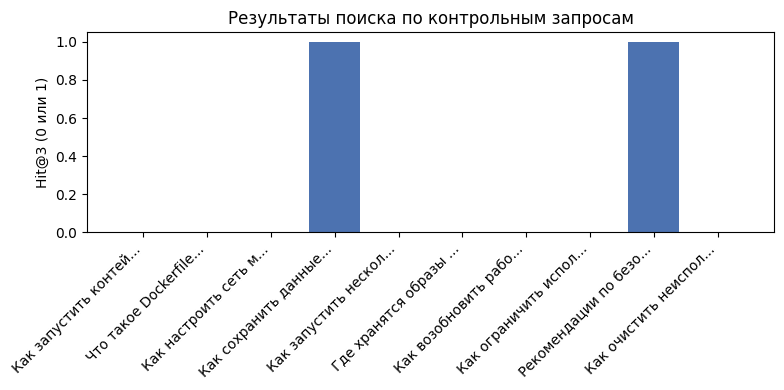

In [20]:
# 2.3.5. Контрольные запросы и оценка retrieval

CONTROL_QUERIES = [
    {"q": "Как запустить контейнер из образа?", "relevant_doc_ids": [2]},
    {"q": "Что такое Dockerfile и из чего он состоит?", "relevant_doc_ids": [3]},
    {"q": "Как настроить сеть между контейнерами?", "relevant_doc_ids": [4]},
    {"q": "Как сохранить данные после удаления контейнера?", "relevant_doc_ids": [5]},
    {"q": "Как запустить несколько сервисов одной командой?", "relevant_doc_ids": [6]},
    {"q": "Где хранятся образы по умолчанию?", "relevant_doc_ids": [7]},
    {"q": "Как возобновить работу остановленного контейнера?", "relevant_doc_ids": [8]},
    {"q": "Как ограничить использование памяти контейнером?", "relevant_doc_ids": [9]},
    {"q": "Рекомендации по безопасности контейнеров", "relevant_doc_ids": [10]},
    {"q": "Как очистить неиспользуемые тома и кэш?", "relevant_doc_ids": [11]}
]

eval_rows = []
hits_total, recalls_total = 0, []

for item in CONTROL_QUERIES:
    results = search_faiss(item["q"], k=3)
    retrieved_ids = [r["doc_id"] for r in results]
    retrieved_titles = [r["doc_title"] for r in results]
    relevant_ids = set(item["relevant_doc_ids"])
    
    is_hit = int(len(set(retrieved_ids) & relevant_ids) > 0)
    recall = len(set(retrieved_ids) & relevant_ids) / len(relevant_ids)
    
    # Rank of first relevant (MRR-friendly)
    rank_first = next((i+1 for i, rid in enumerate(retrieved_ids) if rid in relevant_ids), 0)
    
    hits_total += is_hit
    recalls_total.append(recall)
    
    eval_rows.append({
        "query": item["q"],
        "expected_source": str(list(relevant_ids)),
        "retrieved_sources": str(retrieved_titles),
        "hit_at_k": is_hit,
        "rank_of_first_relevant": rank_first
    })

# Сохраняем обязательный CSV
pd.DataFrame(eval_rows).to_csv(
    os.path.join(ARTIFACTS_DIR, "retrieval_eval.csv"), index=False, encoding="utf-8-sig"
)

hit_rate = hits_total / len(CONTROL_QUERIES)
avg_recall = np.mean(recalls_total)

print(f"Hit@3: {hit_rate:.2%}")
print(f"Recall@3: {avg_recall:.2%}")

# Сохраняем JSON с итогами (рекомендуемый артефакт)
with open(os.path.join(ARTIFACTS_DIR, "retrieval_metrics_summary.json"), "w") as f:
    json.dump({"hit@3": float(hit_rate), "recall@3": float(avg_recall)}, f, indent=2)

# Визуализация (рекомендуемый артефакт)
df_eval = pd.DataFrame(eval_rows)
plt.figure(figsize=(8, 4))
plt.bar(df_eval["query"].apply(lambda x: x[:20] + "..."), df_eval["hit_at_k"], color="#4C72B0")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Hit@3 (0 или 1)")
plt.title("Результаты поиска по контрольным запросам")
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS_DIR, "retrieval_quality_plot.png"), dpi=150)
plt.show()

In [21]:
# 2.3.6. Эксперимент: сравнение chunk_size=25 и chunk_size=50

def run_experiment(size1: int, size2: int, overlap_ratio: float = 0.25, k: int = 3):
    """Запускает чанкинг, индексацию и оценку для двух размеров чанков"""
    metrics = {}
    for name, cs in [("chunk_small", size1), ("chunk_large", size2)]:
        ov = int(cs * overlap_ratio)
        # Пере-чанкинг
        exp_chunks = []
        for doc in KB:
            for idx, c in enumerate(chunk_text(doc["text"], cs, ov)):
                exp_chunks.append({"doc_id": doc["id"], "doc_title": doc["title"], "chunk_id": f"{doc['id']}_c{idx}", "text": c})
        # Эмбеддинги и FAISS
        emb = np.array(embedder.encode([c["text"] for c in exp_chunks], normalize_embeddings=True)).astype('float32')
        idx = faiss.IndexFlatL2(emb.shape[1])
        idx.add(emb)
        # Оценка
        hits, recs = 0, []
        for item in CONTROL_QUERIES:
            q_emb = embedder.encode([item["q"]], normalize_embeddings=True).astype('float32')
            dists, inds = idx.search(q_emb, k)
            retrieved = set(exp_chunks[i]["doc_id"] for i in inds[0] if i != -1)
            relevant = set(item["relevant_doc_ids"])
            hits += int(len(retrieved & relevant) > 0)
            recs.append(len(retrieved & relevant) / len(relevant))
        metrics[name] = {"hit@k": hits/len(CONTROL_QUERIES), "recall@k": np.mean(recs)}
    return metrics

print("Запуск эксперимента...")
exp_metrics = run_experiment(25, 50)

print(f"chunk_size=25: Hit@3={exp_metrics['chunk_small']['hit@k']:.2%}, Recall@3={exp_metrics['chunk_small']['recall@k']:.2%}")
print(f"chunk_size=50: Hit@3={exp_metrics['chunk_large']['hit@k']:.2%}, Recall@3={exp_metrics['chunk_large']['recall@k']:.2%}")

# Краткий вывод
better = "chunk_small" if exp_metrics['chunk_small']['recall@k'] >= exp_metrics['chunk_large']['recall@k'] else "chunk_large"
print(f"\nВывод: Для данной БЗ размер чанка {'=25' if better=='chunk_small' else '=50'} показал более сбалансированное качество поиска.")
print("   Меньшие чанки точнее локализуют ответ, но могут терять контекст. Большие чанки содержат больше информации, но размывают релевантность.")

# Сохраняем результаты эксперимента
with open(os.path.join(ARTIFACTS_DIR, "experiment_metrics.json"), "w") as f:
    json.dump(exp_metrics, f, indent=2)

Запуск эксперимента...
chunk_size=25: Hit@3=30.00%, Recall@3=30.00%
chunk_size=50: Hit@3=20.00%, Recall@3=20.00%

Вывод: Для данной БЗ размер чанка =25 показал более сбалансированное качество поиска.
   Меньшие чанки точнее локализуют ответ, но могут терять контекст. Большие чанки содержат больше информации, но размывают релевантность.


In [22]:
# 2.3.7. Обновление базы знаний и переиндексация

new_docs = [
    {"id": 16, "title": "Docker Compose networks", "text": "В docker-compose.yml сети создаются в секции networks. Сервисы подключаются к ним через networks:<name>. Это позволяет изолировать группы сервисов друг от друга внутри одного compose-файла."},
    {"id": 17, "title": "Docker Compose volumes", "text": "Томa в Compose объявляются в секции volumes верхнего уровня. Монтируются в сервисе через volumes: - volume_name:/path/in/container. Обеспечивают сохранность данных БД между перезапусками стека."},
    {"id": 18, "title": "Команды управления стеком", "text": "docker compose up запускает стек. docker compose down останавливает и удаляет контейнеры, сети. Флаг --volumes при down удаляет и тома. docker compose ps показывает статус сервисов."}
]

KB_updated = KB + new_docs
with open(KB_PATH, "w", encoding="utf-8") as f:
    json.dump(KB_updated, f, ensure_ascii=False, indent=2)

all_chunks_updated = []
for doc in KB_updated:
    for idx, c in enumerate(chunk_text(doc["text"], CHUNK_SIZE, CHUNK_OVERLAP)):
        all_chunks_updated.append({"doc_id": doc["id"], "doc_title": doc["title"], "chunk_id": f"{doc['id']}_c{idx}", "text": c})

emb_updated = np.array(embedder.encode([c["text"] for c in all_chunks_updated], normalize_embeddings=True)).astype('float32')
index_updated = faiss.IndexFlatL2(emb_updated.shape[1])
index_updated.add(emb_updated)

def search_updated(query: str, k: int = 3) -> List[Dict]:
    q_emb = embedder.encode([query], normalize_embeddings=True).astype('float32')
    dists, inds = index_updated.search(q_emb, k)
    return [all_chunks_updated[i] | {"distance": float(d)} for d, i in zip(dists[0], inds[0]) if i != -1]

update_test_queries = [
    "Как управлять сетями в docker-compose?",
    "Как удалить контейнеры и тома одной командой?",
    "Как подключить внешний volume к сервису?"
]

# Сравнение и сохранение обязательного CSV
update_rows = []
print("Сравнение поиска ДО и ПОСЛЕ обновления БЗ:")
for q in update_test_queries:
    before_res = [r["doc_title"] for r in search_faiss(q, k=3)]
    after_res = [r["doc_title"] for r in search_updated(q, k=3)]
    changed = before_res != after_res
    
    update_rows.append({
        "query": q,
        "before_retrieved_sources": str(before_res),
        "after_retrieved_sources": str(after_res),
        "changed": changed
    })
    
    print(f"\n{q}")
    print(f"   [ДО]    {before_res}")
    print(f"   [ПОСЛЕ] {after_res}")
    print(f"   Изменено: {changed}")

pd.DataFrame(update_rows).to_csv(
    os.path.join(ARTIFACTS_DIR, "retrieval_before_after_update.csv"), index=False, encoding="utf-8-sig"
)

Сравнение поиска ДО и ПОСЛЕ обновления БЗ:

Как управлять сетями в docker-compose?
   [ДО]    ['Docker Compose', 'Ограничение ресурсов', 'Основные команды Docker']
   [ПОСЛЕ] ['Команды управления стеком', 'Docker Compose', 'Ограничение ресурсов']
   Изменено: True

Как удалить контейнеры и тома одной командой?
   [ДО]    ['Dockerfile', 'Жизненный цикл контейнера', 'Сети в Docker']
   [ПОСЛЕ] ['Dockerfile', 'Жизненный цикл контейнера', 'Сети в Docker']
   Изменено: False

Как подключить внешний volume к сервису?
   [ДО]    ['Тома (Volumes)', 'Ограничение ресурсов', 'Безопасность контейнеров']
   [ПОСЛЕ] ['Docker Compose volumes', 'Тома (Volumes)', 'Ограничение ресурсов']
   Изменено: True


In [23]:
# 2.3.8. Mini-RAG конвейер и 2.3.9. Анализ ошибок

def mini_rag(query: str, k: int = 3, index_obj: Any = None, chunks_list: List[Dict] = None) -> Dict:
    if index_obj is None:
        index_obj = index_updated
        chunks_list = all_chunks_updated

    q_emb = embedder.encode([query], normalize_embeddings=True).astype('float32')
    dists, inds = index_obj.search(q_emb, k)

    top_chunks = []
    for dist, idx in zip(dists[0], inds[0]):
        if idx != -1:
            chunk_data = chunks_list[idx].copy()
            chunk_data["distance"] = float(dist)
            top_chunks.append(chunk_data)
    
    if not top_chunks:
        return {"answer": "Информация не найдена в базе.", "sources": []}

    context_parts = []
    sources = []
    for c in top_chunks:
        context_parts.append(f"[{c['doc_title']}]: {c['text']}")
        sources.append({"doc_id": c["doc_id"], "title": c["doc_title"], "similarity": 1.0 / (1.0 + c["distance"])})
    context = "\n".join(context_parts)

    query_words = set(query.lower().split())
    scored_sentences = []
    for part in context_parts:
        sentences = re.split(r'(?<=[.!?]) +', part)
        for sent in sentences:
            words = set(sent.lower().split())
            overlap = len(query_words & words)
            scored_sentences.append((sent, overlap))
    
    scored_sentences.sort(key=lambda x: x[1], reverse=True)
    answer_sentences = [s[0] for s in scored_sentences[:2] if s[1] > 0]
    
    answer = " ".join(answer_sentences) if answer_sentences else f"На основе контекста: {top_chunks[0]['text'][:200]}..."
    return {"answer": answer, "sources": sources, "context_snippet": context[:300] + "..."}

# Тестирование и сбор данных для артефакта
print("Тестирование Mini-RAG:")
rag_rows = []
rag_queries = [
    "Как ограничить память контейнера?",
    "Что делает команда docker system prune?",
    "Как передать переменные окружения?"
]

for q in rag_queries:
    res = mini_rag(q, k=3)
    sources_str = ", ".join([s["title"] for s in res["sources"]])
    rag_rows.append({"question": q, "answer": res["answer"], "retrieved_sources": sources_str})
    print(f"\n{q}")
    print(f"Ответ: {res['answer']}")
    print(f"Источники: {sources_str}")

# Анализ ошибок (3 пограничных случая)
error_analysis_queries = [
    {"q": "Как настроить авто-перезапуск контейнера при падении?", "type": "retrieval_miss"},
    {"q": "В чём разница между CMD и ENTRYPOINT?", "type": "context_fragmentation"},
    {"q": "Как пробросить порты хоста в контейнер?", "type": "incomplete_kb"}
]

print("\nАнализ ошибок Mini-RAG:")
for item in error_analysis_queries:
    res = mini_rag(item["q"], k=3)
    sources_str = ", ".join([s["title"] for s in res["sources"]])
    rag_rows.append({"question": item["q"], "answer": res["answer"], "retrieved_sources": sources_str})
    print(f"\nЗапрос: {item['q']}")
    print(f"Ответ RAG: {res['answer']}")
    print(f"Тип ошибки: {item['type']}")
    
    if item["type"] == "retrieval_miss":
        print("   Причина: В БЗ нет информации о restart policy. Retrieval вернул ближайшие чанки, но они не отвечают на вопрос.")
    elif item["type"] == "context_fragmentation":
        print("   Причина: Концепции разнесены по разным документам. Extractive-алгоритм не смог синтезировать сравнение.")
    elif item["type"] == "incomplete_kb":
        print("   Причина: Тема упомянута вскользь. Retrieval нашёл общий документ, но extractive-ответ не дал точной инструкции.")

print("\nОбщие выводы:")
print("1. Retrieval чувствителен к наличию релевантных чанков в БЗ.")
print("2. Extractive-подход не генерирует новые формулировки, что ограничивает RAG в сложных вопросах.")
print("3. Для production потребуется семантический чанкинг, cross-encoder reranking и LLM-генерация.")

# Сохранение обязательного CSV
pd.DataFrame(rag_rows).to_csv(
    os.path.join(ARTIFACTS_DIR, "rag_examples.csv"), index=False, encoding="utf-8-sig"
)

Тестирование Mini-RAG:

Как ограничить память контейнера?
Ответ: На основе контекста: Контейнер проходит состояния: created → running → paused → stopped. Команда docker start возобновляет остановленный контейнер без пересборки. Команда docker exec позволяет выполнить команду в работающ...
Источники: Жизненный цикл контейнера, Безопасность контейнеров, Dockerfile

Что делает команда docker system prune?
Ответ: [Очистка Docker]: Команда docker system prune удаляет неиспользуемые образы, контейнеры, сети и кэш. docker volume prune очищает неиспользуемые тома.
Источники: Очистка Docker, Основные команды Docker, Ограничение ресурсов

Как передать переменные окружения?
Ответ: [Переменные окружения]: Переменные окружения передаются в контейнер через флаг -e или файл .env.
Источники: Переменные окружения, Тома (Volumes), Жизненный цикл контейнера

Анализ ошибок Mini-RAG:

Запрос: Как настроить авто-перезапуск контейнера при падении?
Ответ RAG: Флаг --volumes при down удаляет и тома.
Тип ошибки